## PERFORMANCE ANALYSIS

In [27]:
import argparse
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import models, transforms

In [29]:
TREE_LABELS_CSV = "labels.csv"
TREE_IMAGE_DIR = "processed_data"
TREE_WEIGHTS_PATH = "weights/stein_net_best.pth"

NAV_VAL_CSV = "path_processed/path_labels_val.csv"
NAV_IMAGE_DIR = "path_training_data"
NAV_WEIGHTS_PATH = "weights/path_nav_net_best.pth"
NAV_FULL_CSV = "path_processed/path_labels_full.csv"

IMG_W = 1280.0
IMG_H = 720.0

In [ ]:
full_df = pd.read_csv(TREE_LABELS_CSV)

_, val_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=42
)

val_df = val_df.reset_index(drop=True)

tree_model = torch.load(
    TREE_WEIGHTS_PATH,
    map_location=device,
    weights_only=False
)

tree_model.to(device)
tree_model.eval()

tree_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

rows = []

with torch.no_grad():

    for _, row in val_df.iterrows():

        img_path = os.path.join(
            TREE_IMAGE_DIR,
            row["filename"]
        )

        if not os.path.exists(img_path):
            continue

        image = Image.open(img_path).convert("RGB")

        input_tensor = (
            tree_transform(image)
            .unsqueeze(0)
            .to(device)
        )

        out = (
            tree_model(input_tensor)[0]
            .detach()
            .cpu()
            .numpy()
        )

        pred_x = float(max(0.0, min(1.0, out[0])))
        pred_y = float(max(0.0, min(1.0, out[1])))

        dx = (pred_x - float(row["x"])) * IMG_W
        dy = (pred_y - float(row["y"])) * IMG_H

        px_err = math.sqrt(dx * dx + dy * dy)

        mse_xy = (
            ((pred_x - float(row["x"])) ** 2) +
            ((pred_y - float(row["y"])) ** 2)
        ) / 2.0

        rows.append({
            "x": float(row["x"]),
            "y": float(row["y"]),
            "pred_x": pred_x,
            "pred_y": pred_y,
            "pixel_error": px_err,
            "mse_xy": mse_xy,
        })

tree_df = pd.DataFrame(rows)

print(f"Tree samples evaluated: {len(tree_df)}")

Tree samples evaluated: 223


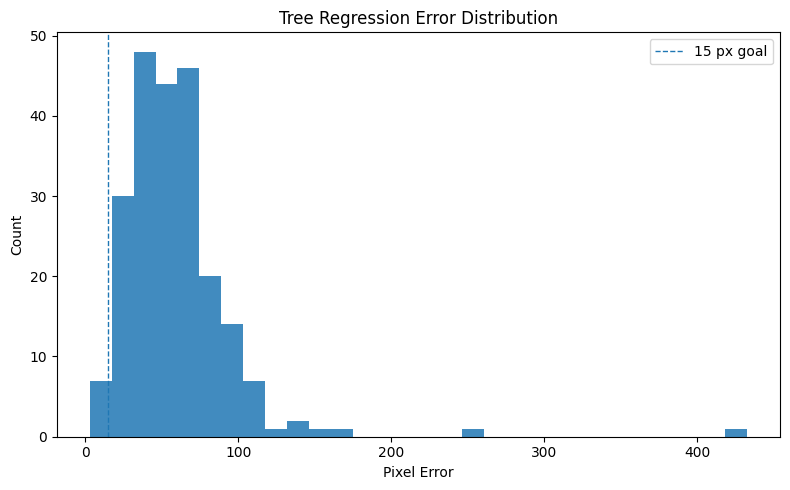

In [34]:
# Tree Error
plt.figure(figsize=(8, 5))
plt.hist(
    tree_df["pixel_error"],
    bins=30,
    alpha=0.85
)
plt.axvline(
    15,
    linestyle="--",
    linewidth=1,
    label="15 px goal"
)
plt.xlabel("Pixel Error")
plt.ylabel("Count")

plt.title("Tree Regression Error Distribution")
plt.legend()
plt.tight_layout()
plt.show()


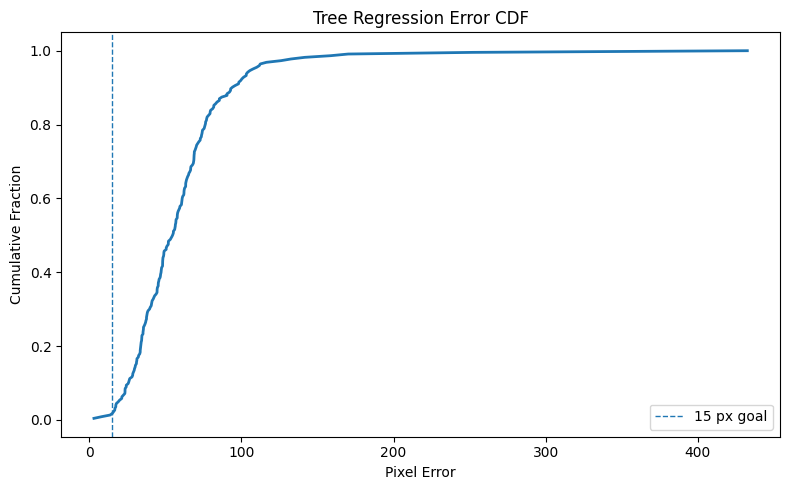

In [35]:
# Tree Error CDF
vals = np.sort(
    tree_df["pixel_error"].to_numpy()
)

cdf = np.arange(
    1,
    len(vals) + 1
) / len(vals)

plt.figure(figsize=(8, 5))
plt.plot(vals, cdf, linewidth=2)
plt.axvline(
    15,
    linestyle="--",
    linewidth=1,
    label="15 px goal"
)

plt.xlabel("Pixel Error")
plt.ylabel("Cumulative Fraction")
plt.title("Tree Regression Error CDF")

plt.legend()
plt.tight_layout()
plt.show()

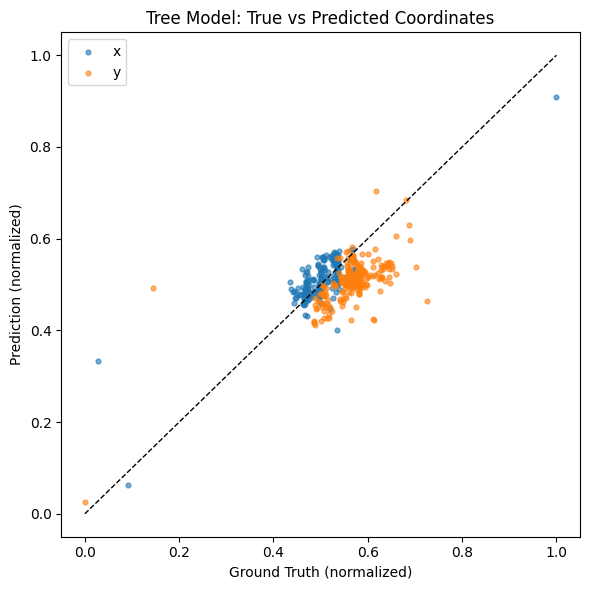

In [ ]:
# True v. Predicted for Tree

plt.figure(figsize=(6, 6))

plt.scatter(
    tree_df["x"],
    tree_df["pred_x"],
    s=12,
    alpha=0.6,
    label="x"
)

plt.scatter(
    tree_df["y"],
    tree_df["pred_y"],
    s=12,
    alpha=0.6,
    label="y"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    color="black"
)

plt.xlabel("Ground Truth (normalized)")
plt.ylabel("Prediction (normalized)")

plt.title(
    "Tree Model: True vs Predicted Coordinates"
)

plt.legend()
plt.tight_layout()
plt.show()

In [37]:
payload = torch.load(
    NAV_WEIGHTS_PATH,
    map_location=device
)

if (
    not isinstance(payload, dict)
    or "model_state_dict" not in payload
):
    raise RuntimeError(
        "Nav weights format is invalid."
    )

id_to_action = payload.get(
    "id_to_action",
    {
        0: "forward",
        1: "left",
        2: "backward",
        3: "right"
    }
)

id_to_action = {
    int(k): str(v)
    for k, v in id_to_action.items()
}

num_classes = int(
    payload.get(
        "num_classes",
        len(id_to_action)
    )
)

nav_model = models.resnet18(weights=None)

nav_model.fc = nn.Linear(
    nav_model.fc.in_features,
    num_classes
)

nav_model.load_state_dict(
    payload["model_state_dict"]
)

nav_model.to(device)
nav_model.eval()
nav_df = pd.read_csv(
    NAV_VAL_CSV
).reset_index(drop=True)

nav_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

In [38]:
y_true = []
y_pred = []

with torch.no_grad():

    for _, row in nav_df.iterrows():

        img_path = os.path.join(
            NAV_IMAGE_DIR,
            row["filename"]
        )
        if not os.path.exists(img_path):
            continue
        image = Image.open(img_path).convert("RGB")
        tensor = (
            nav_transform(image)
            .unsqueeze(0)
            .to(device)
        )
        pred = int(
            torch.argmax(
                nav_model(tensor),
                dim=1
            ).item()
        )

        y_true.append(int(row["label_id"]))
        y_pred.append(pred)

labels = sorted(
    set(y_true) | set(y_pred)
)
mat = np.zeros(
    (len(labels), len(labels)),
    dtype=np.int32
)
label_to_idx = {
    l: i
    for i, l in enumerate(labels)
}
for t, p in zip(y_true, y_pred):

    mat[
        label_to_idx[t],
        label_to_idx[p]
    ] += 1

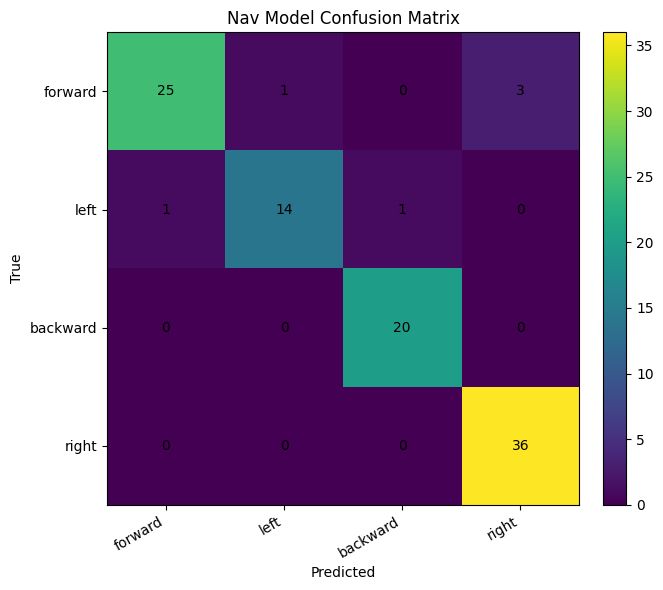

In [39]:
names = [
    id_to_action.get(l, str(l))
    for l in labels
]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    mat,
    interpolation="nearest"
)

ax.set_title("Nav Model Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))

ax.set_xticklabels(
    names,
    rotation=30,
    ha="right"
)
ax.set_yticklabels(names)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):

        ax.text(
            j,
            i,
            str(mat[i, j]),
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()
plt.show()

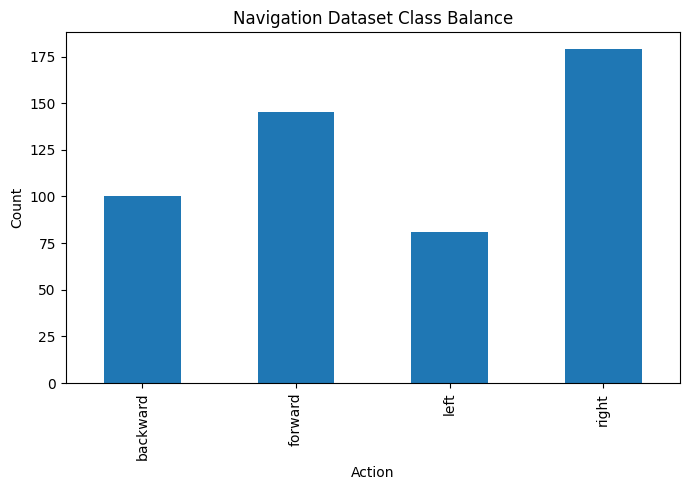

In [40]:
full_nav_df = pd.read_csv(NAV_FULL_CSV)

if "action" in full_nav_df.columns:

    counts = (
        full_nav_df["action"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(7, 5))

    counts.plot(kind="bar")

    plt.title(
        "Navigation Dataset Class Balance"
    )

    plt.xlabel("Action")
    plt.ylabel("Count")

    plt.tight_layout()

    plt.show()

In [42]:
summary = {
    "tree_samples": int(len(tree_df)),
    "tree_mse_xy": float(tree_df["mse_xy"].mean()),
    "tree_pixel_mean": float(
        tree_df["pixel_error"].mean()
    ),
    "tree_pixel_median": float(
        tree_df["pixel_error"].median()
    ),
    "tree_pixel_p90": float(
        tree_df["pixel_error"].quantile(0.90)
    ),
    "tree_pixel_p95": float(
        tree_df["pixel_error"].quantile(0.95)
    ),
    "tree_under_15_pct": float(
        (
            tree_df["pixel_error"] < 15.0
        ).mean() * 100.0
    ),
    "tree_under_25_pct": float(
        (
            tree_df["pixel_error"] < 25.0
        ).mean() * 100.0
    ),
    "tree_under_40_pct": float(
        (
            tree_df["pixel_error"] < 40.0
        ).mean() * 100.0
    ),
}

summary_df = pd.Series(summary)

display(summary_df)

tree_samples         223.000000
tree_mse_xy            0.003471
tree_pixel_mean       59.303813
tree_pixel_median     54.929965
tree_pixel_p90        93.893580
tree_pixel_p95       107.456625
tree_under_15_pct      1.345291
tree_under_25_pct      9.417040
tree_under_40_pct     30.044843
dtype: float64